# Step 3 - Hyperparameter tuning via Latin hypercube search

**Goal:** understand how `tune_model()` in `its2s.tuning` composes Latin hypercube (LHS) sampling with the step-2 cross-validation to pick model hyperparameters, and how to plug the result into `run_single_its()`.

**Scope of this notebook -- demo only.** `tune_model()` supports four models (`arima`, `neuralprophet`, `prophet_xgb`, `prophet_then_xgb`) each with its own search space. To keep the notebook short and focused, the executable demo below tunes **`prophet_xgb` only**. The same mechanics apply to the other three models -- swap `model_name` and set `n_trials` accordingly (100 for arima / prophet_xgb / prophet_then_xgb, 75 for neuralprophet; these are the defaults exposed via `get_tuning_config()`).

Sections:
- **3a.** Per-model search spaces: what is being tuned and how.
- **3b.** Latin hypercube vs. random sampling: why LHS gets better coverage at small budgets.
- **3c.** One tuning run on `prophet_xgb`.
- **3d.** `_unflatten_params`: flat LHS keys -> nested config overrides.
- **3e.** Using `best_params` in `run_single_its()`.
- **3f.** `get_tuning_config()` and `params.yaml` defaults.
- **3g.** Closing the loop with step 2: `cv_kwargs` and leakage-free tuning.

In [1]:
%matplotlib inline

import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

from its2s.tuning import tune_model, _SEARCH_SPACES, _sample_lhs, _unflatten_params
from its2s.settings import load_config, get_tuning_config

OUT_DIR = Path.cwd() / 'figures'
OUT_DIR.mkdir(exist_ok=True)

DATA = Path('data/dummy_data.csv')
INTERVENTION = pd.Timestamp('2022-03-15')
TEST_DAYS = 90

df = pd.read_csv(DATA, parse_dates=['ds']).sort_values('ds').reset_index(drop=True)
print(f'n={len(df)} rows, intervention={INTERVENTION.date()}')


n=1576 rows, intervention=2022-03-15


## 3a. Per-model search spaces

Each search space is a dict: `param_name -> (low, high, dtype, scale)`.

- **`dtype`**: `'int'` (rounded and clamped) or `'float'`.
- **`scale`**: `'linear'` (uniform) or `'log'` (log-uniform -- right for parameters that span orders of magnitude, e.g. learning rates, regularization strengths).
- **Nested keys**: `'section__param'` gets unflattened into `{'section': {'param': value}}` before injection. That is how `prophet__changepoint_prior_scale` reaches the right sub-config.

ARIMA is a partial exception: rather than tuning fixed ARIMA orders `(p,d,q,P,D,Q)` directly, `ARIMAModel` uses `pmdarima.auto_arima` with upper bounds (`max_p`, `max_d`, ...). Tuning these bounds changes the *search space available to auto_arima* rather than fixing an order. If you tuned fixed orders instead, you would need to evaluate each `(p,d,q)` combination explicitly and select the best. Report the upper-bound approach in any downstream writeup.

In [2]:
for name, space in _SEARCH_SPACES.items():
    print(f'--- {name} ({len(space)} params) ---')
    for k, v in space.items():
        low, high, dtype, scale = v
        print(f'  {k:<42} {dtype:<6} {scale:<6} [{low}, {high}]')
    print()


--- prophet_xgb (10 params) ---
  prophet__changepoint_prior_scale           float  log    [0.01, 0.5]
  prophet__seasonality_prior_scale           float  log    [0.1, 10.0]
  prophet__changepoint_range                 float  linear [0.4, 0.9]
  xgb__n_estimators                          int    linear [50, 500]
  xgb__max_depth                             int    linear [4, 20]
  xgb__learning_rate                         float  log    [0.001, 0.3]
  xgb__min_child_weight                      int    linear [1, 12]
  xgb__subsample                             float  linear [0.6, 1.0]
  xgb__colsample_bytree                      float  linear [0.5, 1.0]
  xgb__gamma                                 float  log    [0.001, 5.0]

--- prophet_then_xgb (10 params) ---
  prophet__changepoint_prior_scale           float  log    [0.01, 0.5]
  prophet__seasonality_prior_scale           float  log    [0.1, 10.0]
  prophet__changepoint_range                 float  linear [0.4, 0.9]
  xgb__n_estimators

## 3b. Latin hypercube vs. random sampling

At small trial budgets (75-100), plain random sampling can leave whole subregions of the space unexplored. Latin hypercube (LHS) stratifies the unit cube so that each axis is covered evenly. The 2D projection below makes the difference visible: LHS is evenly spread; random clumps and leaves gaps.

Under the hood `_sample_lhs()` uses `scipy.stats.qmc.LatinHypercube`, samples from the unit hypercube, then rescales each column to its declared range (linear or log) and rounds/clamps integer columns.


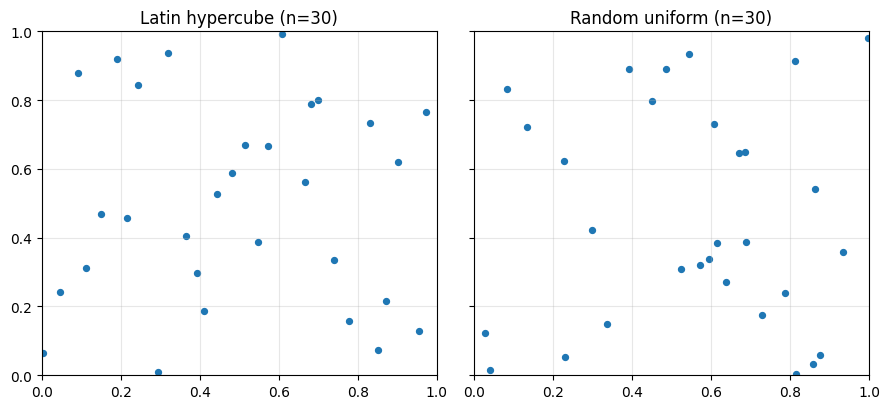

In [3]:
from scipy.stats import qmc
n = 30
lhs = qmc.LatinHypercube(d=2, seed=0).random(n=n)
rnd = np.random.default_rng(0).random((n, 2))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharex=True, sharey=True)
for ax, pts, title in [(axes[0], lhs, f'Latin hypercube (n={n})'),
                       (axes[1], rnd, f'Random uniform (n={n})')]:
    ax.scatter(pts[:, 0], pts[:, 1], s=18)
    ax.set_xticks(np.linspace(0, 1, 6)); ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_title(title); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / 'step3b_lhs_vs_random.png', dpi=150)
display(fig)


In [4]:
# Peek at what _sample_lhs returns for the prophet_xgb space.
sample_trials = _sample_lhs(_SEARCH_SPACES['prophet_xgb'], n_trials=5, seed=42)
display(pd.DataFrame(sample_trials))


,prophet__changepoint_prior_scale,prophet__seasonality_prior_scale,prophet__changepoint_range,xgb__n_estimators,xgb__max_depth,xgb__learning_rate,xgb__min_child_weight,xgb__subsample,xgb__colsample_bytree,xgb__gamma
0,0.011935,6.674959,0.414140,77,10,0.031503,2,0.857115,0.787189,2.321545
1,0.078232,1.695485,0.535613,426,6,0.007556,6,0.994895,0.617237,0.056504
2,0.276297,1.143377,0.602930,150,18,0.024538,9,0.676496,0.984571,0.009425
3,0.026701,0.103038,0.767417,377,12,0.002521,5,0.801944,0.577309,0.001755
4,0.162418,0.293041,0.829973,292,14,0.119790,11,0.736934,0.831750,0.717444


## 3c. A tuning run on prophet_xgb

`tune_model()` evaluates every sampled combination via `time_series_cv()` and keeps the one with the lowest mean CV RMSE (or MAE if `metric='mae'`). Each trial is independent, so `n_jobs>1` parallelises across trials.

Below we use a small budget (`n_trials=8`, `n_folds=3`, `test_obs=90`, `min_train_obs=365`) so the notebook finishes in a reasonable time. Production runs should use `split_method='observations'`, `n_trials=100`, `n_folds=5`, `test_obs=365`, `min_train_obs=730`, `skip_obs=365` (the R-reference settings on daily data; `get_tuning_config()` surfaces the values set in `params.yaml` -- see 3f).

Failed trials do not abort the search; `_evaluate_trial` catches exceptions and assigns `inf` RMSE so the bad combination is simply never selected.

In [5]:
# Demo run -- small budget for notebook execution speed.
result = tune_model(
    df=df,
    intervention_date=INTERVENTION,
    model_name='prophet_xgb',
    n_trials=8,
    n_folds=3,
    split_method='observations',
    test_obs=90,
    min_train_obs=365,
    skip_obs=0,
    metric='rmse',
    n_jobs=1,
    seed=42,
)

print('model_name:   ', result.model_name)
print('n_trials:     ', result.n_trials)
print('n_folds:      ', result.n_folds)
print('metric:       ', result.metric)
print('seed:         ', result.seed)
print('cv_end_date:  ', result.cv_end_date.date())
print(f'best_rmse:     {result.best_rmse:.4f} +/- {result.best_std_rmse:.4f}')
print('best_params:  ')
for section, params in result.best_params.items():
    print(f'  {section}:')
    if isinstance(params, dict):
        for k, v in params.items():
            print(f'    {k}: {v}')
    else:
        print(f'    {params}')


model_name:    prophet_xgb
n_trials:      8
n_folds:       3
metric:        rmse
seed:          42
best_rmse:     2.0016 +/- 0.1288
best_params:  
  prophet:
    changepoint_prior_scale: 0.03501670294289283
    seasonality_prior_scale: 0.11011093513903454
    changepoint_range: 0.7312334311248594
  xgb:
    n_estimators: 145
    max_depth: 18
    learning_rate: 0.0011493513094884857
    min_child_weight: 5
    subsample: 0.8355835948034878
    colsample_bytree: 0.957344031001564
    gamma: 0.512401004717215


In [6]:
# trials_df: one row per sampled parameter combination.
display(result.trials_df.sort_values('mean_rmse').head(10))


,trial_id,prophet__changepoint_prior_scale,prophet__seasonality_prior_scale,prophet__changepoint_range,xgb__n_estimators,xgb__max_depth,xgb__learning_rate,xgb__min_child_weight,xgb__subsample,xgb__colsample_bytree,xgb__gamma,mean_rmse,std_rmse,mean_mae,mean_mape,mean_r2,n_folds_ok
4,4,0.035017,0.110111,0.731233,145,18,0.001149,5,0.835584,0.957344,0.512401,2.001638,0.128815,1.580194,2.985877,0.836359,3
6,6,0.019178,0.428772,0.427173,288,5,0.011672,6,0.784802,0.873074,0.005282,2.018697,0.103391,1.597179,3.024430,0.835085,3
7,7,0.103821,0.790438,0.659162,206,14,0.003405,9,0.866904,0.902685,0.089003,2.030196,0.143383,1.593584,3.010889,0.830868,3
1,1,0.255771,1.043059,0.859758,60,9,0.007220,3,0.996809,0.635773,2.552152,2.033323,0.168972,1.606641,3.033899,0.828847,3
2,2,0.129787,2.578508,0.776831,337,10,0.030756,10,0.747810,0.552857,0.011784,2.138810,0.141059,1.679816,3.185971,0.813978,3
0,0,0.011169,7.767484,0.596338,405,16,0.073348,11,0.660697,0.804493,0.001795,2.240067,0.127200,1.781315,3.380512,0.799098,3
5,5,0.064125,0.314890,0.538317,463,7,0.171940,7,0.621563,0.741263,1.526312,2.280317,0.051018,1.800838,3.418390,0.794920,3
3,3,0.347379,3.221978,0.504636,254,17,0.062976,2,0.926215,0.610818,0.034656,2.574119,0.143279,2.033045,3.861600,0.734791,3


## 3d. Flat keys to nested config

LHS sampling works on a flat key list (`xgb__max_depth`, `prophet__changepoint_prior_scale`, ...). But the model config dict is nested: `{'xgb': {'max_depth': ...}, 'prophet': {'changepoint_prior_scale': ...}}`. `_unflatten_params` is the bridge.

Top-level params (no `__`) stay at the top level. This is why `arima`'s `max_p`, `max_d`, etc. remain at the root of the model config rather than being grouped.


In [7]:
flat = {
    'xgb__max_depth': 8,
    'xgb__learning_rate': 0.05,
    'prophet__changepoint_prior_scale': 0.1,
    'prophet__seasonality_prior_scale': 5.0,
}
nested = _unflatten_params(flat)
print('flat:'); print(pd.Series(flat), '\n')
print('nested:'); print(nested)

# And for arima (all top-level, no __):
print('\narima example:')
print(_unflatten_params({'max_p': 4, 'max_d': 1, 'max_q': 3}))


flat:
xgb__max_depth                      8.00
xgb__learning_rate                  0.05
prophet__changepoint_prior_scale    0.10
prophet__seasonality_prior_scale    5.00
dtype: float64 

nested:
{'xgb': {'max_depth': 8, 'learning_rate': 0.05}, 'prophet': {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0}}

arima example:
{'max_p': 4, 'max_d': 1, 'max_q': 3}


## 3e. Using best_params

`TuningResult.best_params` is already in nested form -- drop it directly into `config_overrides`:

```python
from its2s import run_single_its
pipeline_result = run_single_its(
    df, intervention_date=INTERVENTION,
    model_name='prophet_xgb',
    config_overrides={'models': {'prophet_xgb': result.best_params}},
)
```

Step 6 (`step6_full_workflow.ipynb`) executes this end-to-end. The package `load_config()` deep-merges `best_params` on top of the `params.yaml` defaults, so any parameter you did not tune (e.g., `yearly_seasonality=True`) is preserved.


## 3f. Tuning config and defaults

`tune_model()` has reasonable defaults, but the *intended* production values live in the `tuning:` section of `its2s/params.yaml`. `get_tuning_config()` surfaces them so you can read them programmatically and pass them straight through.


In [8]:
cfg = load_config()
tuning_cfg = get_tuning_config(cfg)
for k, v in tuning_cfg.items():
    print(f'{k:<18} {v}')


split_method       percent
n_folds            5
test_pct           0.1
min_train_pct      0.5
skip_pct           0.0
test_days          365
min_train_days     730
skip_days          0
metric             rmse
n_jobs             1
seed               42
model_defaults     {'prophet_xgb': 100, 'prophet_then_xgb': 100, 'neuralprophet': 75, 'arima': 100}


## 3g. Closing the loop with step 2

`tune_model()` threads `n_folds`, `test_obs`, `min_train_obs`, `skip_obs`, and `cv_end_date` straight into `time_series_cv()` inside `_evaluate_trial`. That means every design decision from step 2 applies here: the leakage cap `cv_end_date` is derived from the run's split config by default (pass `tune_model` the same `config_overrides` your run will use), and `skip_obs=365` keeps folds well-separated.

The leakage-free invocation looks like:

```python
result = tune_model(
    df, intervention_date, model_name='prophet_xgb',
    n_trials=100,
    split_method='observations',
    n_folds=5, test_obs=365, min_train_obs=730, skip_obs=365,
)
```

## Key takeaways

1. **LHS over random.** Better coverage of the search space at small budgets.
2. **Flat keys on the sampler, nested keys on the config.** `_unflatten_params` is the adapter.
3. **`TuningResult.best_params` is drop-in for `config_overrides`.** No manual remapping.
4. **Tuning inherits all of step 2's CV knobs.** Tuning is leakage-free by default: `cv_end_date` is derived from the run's split config; override it only deliberately.
5. **ARIMA tuning uses upper bounds, not fixed orders.** `auto_arima` selects the best order within those bounds. If you fixed orders directly, you would need to enumerate combinations explicitly. Note this when reporting.
6. **This demo tunes only `prophet_xgb`** for time; the other three models use the same mechanics with their own search spaces and trial counts.